In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import networkx as nx
import ast

# ==========================================================
# 1. CARGA DE DATOS Y EXTRACCIÓN DE TRANSICIONES
# ==========================================================

# Cargamos el dataframe (asegurate de que la ruta sea correcta)
trayectorias = pd.read_excel("C:/Users/micag/Documents/RedesHospitales/data/revision_dfs.xlsx", sheet_name=2)
df_pacientes = pd.read_excel("C:/Users/micag/Documents/RedesHospitales/data/revision_dfs.xlsx", sheet_name=0)


# Usamos un Counter para contar cuántas veces se pasa de un Nivel A a un Nivel B
transiciones = Counter()
niveles_unicos = set()

# Recorremos cada trayectoria para extraer los niveles y sus saltos
for ruta in trayectorias['ruta_complejidad_str'].dropna():
    nodos = [n.strip() for n in str(ruta).split('->')]
    
    # Guardamos los niveles únicos para armar los ejes de la matriz
    for n in nodos:
        niveles_unicos.add(n)
        
    # Contamos las transiciones (origen -> destino)
    for i in range(len(nodos)-1):
        transiciones[(nodos[i], nodos[i+1])] += 1

# Ordenamos los niveles. 
# NOTA: Si tus niveles son strings como 'Baja', 'Media', 'Alta', te conviene 
# forzar el orden manualmente así: niveles = ['Baja', 'Media', 'Alta']
niveles = sorted(list(niveles_unicos))

In [76]:
# ==========================================================
# 2. CONSTRUCCIÓN DE LAS MATRICES (DATAFRAMES)
# ==========================================================

# Matriz de Cantidades
df_cantidades = pd.DataFrame(0, index=niveles, columns=niveles)

for (origen, destino), cantidad in transiciones.items():
    df_cantidades.at[origen, destino] = cantidad

# Matriz de Probabilidades (Frecuencia relativa por fila)
# Dividimos cada celda por la suma total de su fila (hospital de origen)
df_probabilidades = df_cantidades.div(df_cantidades.sum(axis=1), axis=0).fillna(0)


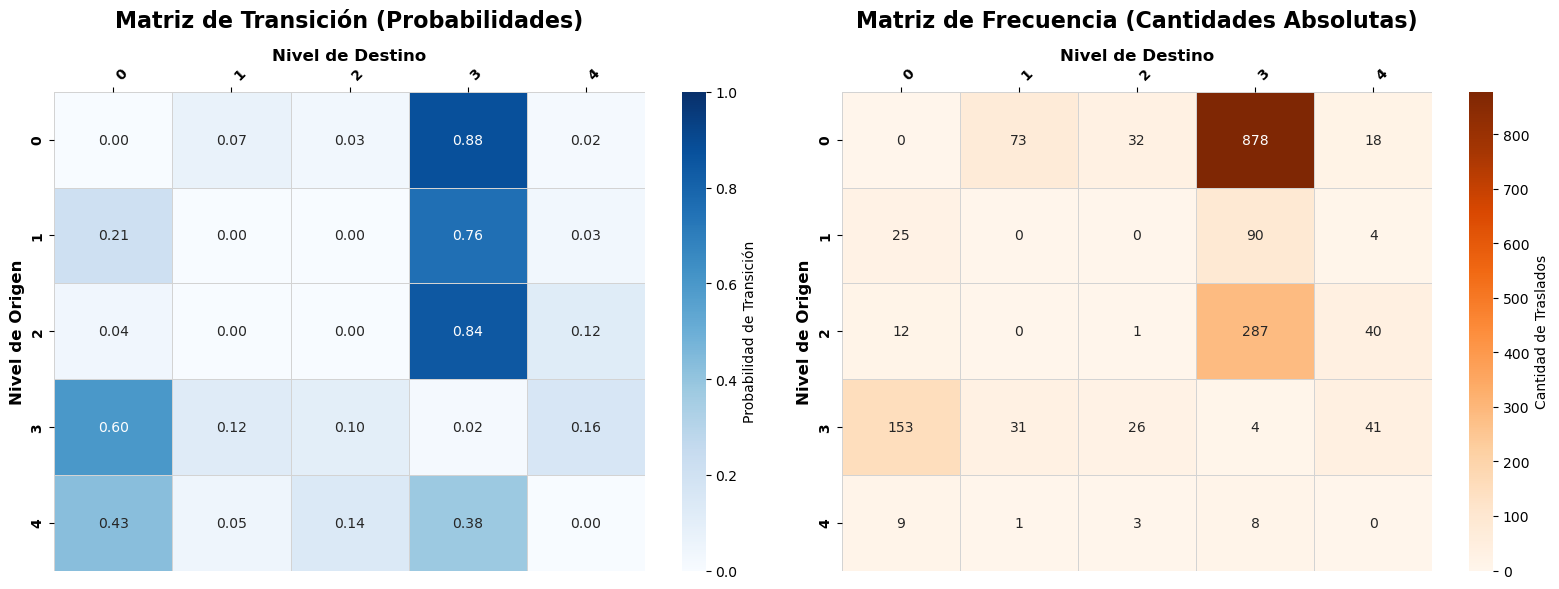

In [ ]:
# ==========================================================
# 3. VISUALIZACIÓN (heatmaps)
# ==========================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

# -- Gráfico 1: Probabilidades --
sns.heatmap(df_probabilidades, annot=True, fmt=".2f", cmap="Blues", 
            linewidths=0.5, linecolor='lightgray', vmin=0, vmax=1, ax=axes[0],
            cbar_kws={'label': 'Probabilidad de Transición'})

axes[0].set_title("Matriz de Transición (Probabilidades)", fontsize=16, fontweight='bold', pad=15)
axes[0].set_ylabel("Nivel de Origen", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Nivel de Destino", fontsize=12, fontweight='bold')

# -- Gráfico 2: Cantidades --
sns.heatmap(df_cantidades, annot=True, fmt="d", cmap="Oranges", 
            linewidths=0.5, linecolor='lightgray', ax=axes[1],
            cbar_kws={'label': 'Cantidad de Traslados'})

axes[1].set_title("Matriz de Frecuencia (Cantidades Absolutas)", fontsize=16, fontweight='bold', pad=15)
axes[1].set_ylabel("Nivel de Origen", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Nivel de Destino", fontsize=12, fontweight='bold')

# Mejoras estéticas para ambos gráficos
for ax in axes:
    ax.xaxis.tick_top() # Eje X arriba (estándar en matrices de transición)
    ax.xaxis.set_label_position('top')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='left', fontweight='bold')
    plt.setp(ax.get_yticklabels(), fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\micag\AppData\Local\Temp\ipykernel_27764\4254121522.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='Frecuencia', y='Ruta', palette='viridis', ax=ax)


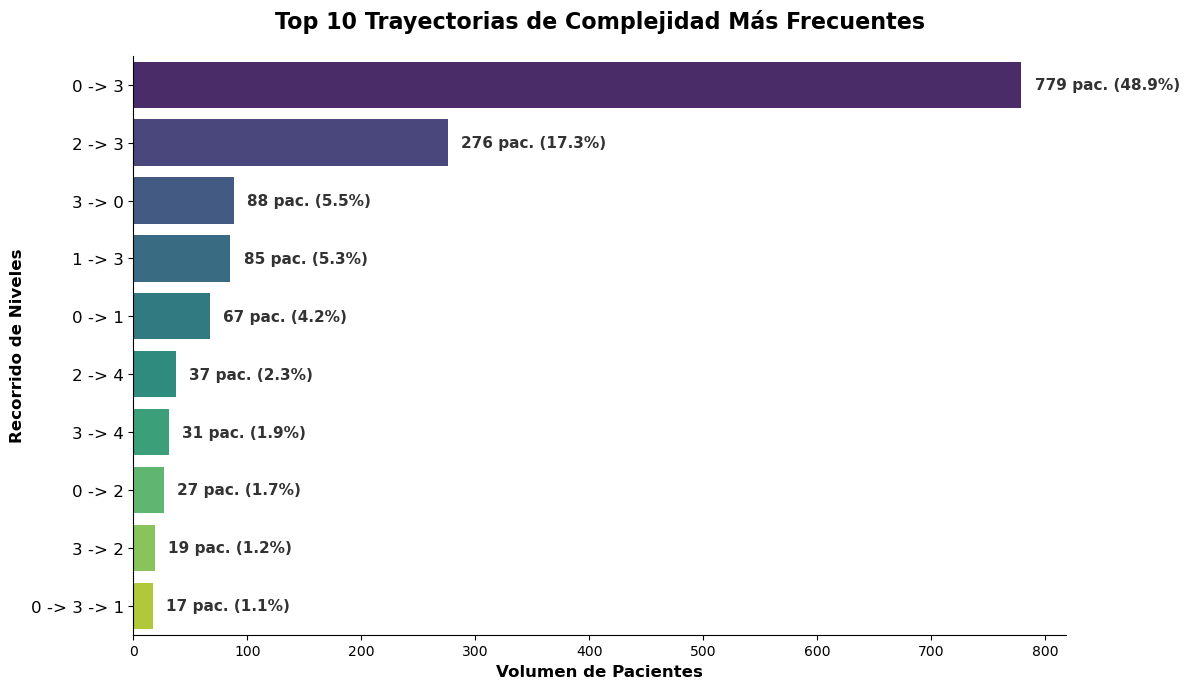

In [84]:
# ==========================================================
# 4. CÁLCULO DE FRECUENCIAS Y PORCENTAJES (TOP 10)
# ==========================================================

# Contamos las rutas y nos quedamos con las 10 principales
top_10 = trayectorias['ruta_complejidad_str'].value_counts().head(10).reset_index()
top_10.columns = ['Ruta', 'Frecuencia']

# Calculamos qué porcentaje representa cada ruta sobre el total de pacientes evaluados
total_pacientes = len(trayectorias.dropna(subset=['ruta_complejidad_array']))
top_10['Porcentaje'] = (top_10['Frecuencia'] / total_pacientes) * 100

# ==========================================================
# 5. VISUALIZACIÓN: GRÁFICO DE BARRAS HORIZONTALES
# ==========================================================

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')

# Dibujamos las barras horizontales usando una paleta que resalte los valores más altos
sns.barplot(data=top_10, x='Frecuencia', y='Ruta', palette='viridis', ax=ax)

# Agregamos las etiquetas de datos (Cantidad y Porcentaje) al final de cada barra
margen = top_10['Frecuencia'].max() * 0.015 # Un pequeño margen para que el texto no se pegue a la barra

for index, row in top_10.iterrows():
    texto_etiqueta = f"{int(row['Frecuencia'])} pac. ({row['Porcentaje']:.1f}%)"
    ax.text(row['Frecuencia'] + margen, index, texto_etiqueta, 
            color='#333333', va="center", fontweight='bold', fontsize=11)

# Estética y limpieza visual
ax.set_title("Top 10 Trayectorias de Complejidad Más Frecuentes", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Volumen de Pacientes", fontsize=12, fontweight='bold')
ax.set_ylabel("Recorrido de Niveles", fontsize=12, fontweight='bold')

# Ocultar los bordes superior y derecho para un look más limpio (estilo reporte)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Agrandar un poco el tamaño de las rutas en el eje Y para mejor lectura
ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.show()

In [83]:
# ==========================================================
# Cheque de representatividad de este top 10
# ==========================================================

# proporcion
total_pacientes_red = len(rutas_validas)
pacientes_en_top_10 = top_10_rutas.sum()
porcentaje_cobertura = (pacientes_en_top_10 / total_pacientes_red) * 100

print(f"Total de pacientes en la red: {total_pacientes_red}")
print(f"Pacientes dentro del Top 10: {pacientes_en_top_10}")
print(f"El Top 10 representa el {porcentaje_cobertura:.2f}% del total de movimientos.")

Total de pacientes en la red: 1593
Pacientes dentro del Top 10: 1426
El Top 10 representa el 89.52% del total de movimientos.


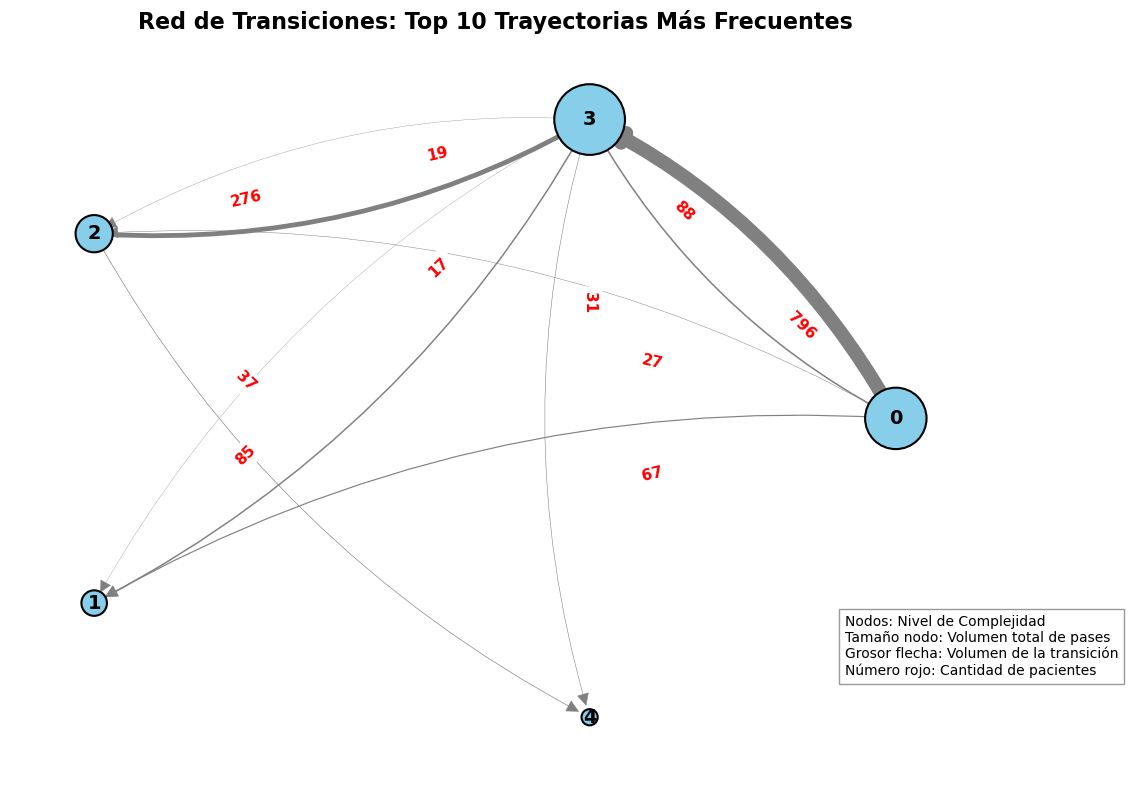

In [ ]:


# ==========================================================
# 1. EXTRACCIÓN Y LIMPIEZA DEL TOP 10
# ==========================================================

# Aseguramos que la columna sea una lista real de Python
def parsear_array(valor):
    if isinstance(valor, str) and valor.startswith('['):
        try:
            return ast.literal_eval(valor)
        except:
            return []
    elif isinstance(valor, list):
        return valor
    return []

trayectorias['lista_nodos'] = trayectorias['ruta_complejidad_array'].apply(parsear_array)

# Filtramos filas vacías y convertimos a tuplas para poder contarlas
rutas_validas = trayectorias[trayectorias['lista_nodos'].map(len) > 0]['lista_nodos'].apply(tuple)

# Obtenemos las 10 rutas más frecuentes con su cantidad exacta
top_10_rutas = rutas_validas.value_counts().head(10)

# ==========================================================
# 2. CONSTRUCCIÓN DEL GRAFO DIRIGIDO (PONDERADO)
# ==========================================================

G_top10 = nx.DiGraph()
pesos_nodos = Counter()
pesos_aristas = Counter()

# Calculamos el peso de cada nodo y arista multiplicando por la frecuencia de la ruta
for ruta, frecuencia in top_10_rutas.items():
    # Sumar peso a los nodos
    for nodo in ruta:
        pesos_nodos[nodo] += frecuencia
        
    # Sumar peso a las transiciones (aristas)
    for i in range(len(ruta) - 1):
        origen = ruta[i]
        destino = ruta[i+1]
        pesos_aristas[(origen, destino)] += frecuencia

# Agregamos los datos al grafo de NetworkX
for nodo, peso in pesos_nodos.items():
    G_top10.add_node(nodo, weight=peso)

for (origen, destino), peso in pesos_aristas.items():
    G_top10.add_edge(origen, destino, weight=peso)

# ==========================================================
# 3. VISUALIZACIÓN DE LA RED
# ==========================================================

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('white')
ax.axis('off')

# Layout circular o spring suele quedar bien para pocos nodos
# Como son niveles de complejidad (0, 1, 2...), un layout circular los ordena bien
posiciones = nx.circular_layout(G_top10)

# Escalamos tamaños para que sea visualmente agradable
tamanos_nodos = [G_top10.nodes[n]['weight'] * 2 for n in G_top10.nodes()]
grosores_aristas = [G_top10.edges[e]['weight'] / (max(pesos_aristas.values()) * 0.1) for e in G_top10.edges()]

# Dibujamos Nodos
nx.draw_networkx_nodes(G_top10, posiciones, ax=ax, 
                       node_color='skyblue', 
                       node_size=tamanos_nodos, 
                       edgecolors='black', linewidths=1.5)

# Dibujamos Etiquetas de los Nodos (Nivel de complejidad)
nx.draw_networkx_labels(G_top10, posiciones, ax=ax, 
                        font_size=14, font_weight='bold', font_color='black')

# Dibujamos Aristas (Flechas)
nx.draw_networkx_edges(G_top10, posiciones, ax=ax, 
                       width=grosores_aristas, 
                       edge_color='gray', 
                       arrowstyle='-|>', arrowsize=20, 
                       connectionstyle="arc3,rad=0.15") # Curvatura para evitar superposición si van y vuelven

# Agregamos el peso (cantidad de pacientes) en las flechas
etiquetas_aristas = {(u, v): d['weight'] for u, v, d in G_top10.edges(data=True)}
nx.draw_networkx_edge_labels(G_top10, posiciones, edge_labels=etiquetas_aristas, 
                             font_color='red', font_weight='bold', font_size=11, label_pos=0.3)

ax.set_title("Red de Transiciones: Top 10 Trayectorias Más Frecuentes", 
             fontsize=16, fontweight='bold', pad=20)

# Leyenda explicativa
texto_info = (f"Nodos: Nivel de Complejidad\n"
              f"Tamaño nodo: Volumen total de pases\n"
              f"Grosor flecha: Volumen de la transición\n"
              f"Número rojo: Cantidad de pacientes")
plt.figtext(0.85, 0.15, texto_info, fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()

C:\Users\micag\AppData\Local\Temp\ipykernel_27764\1195636224.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rutas_4, x='Frecuencia', y='Ruta', palette='magma', ax=ax)


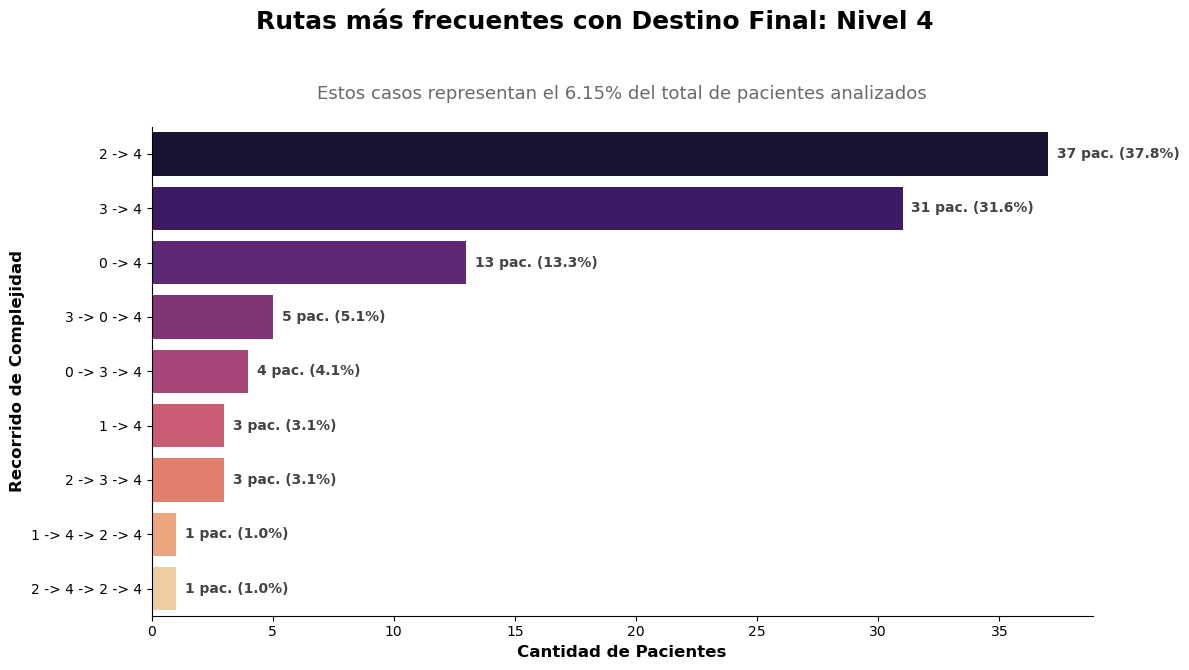

--- ANÁLISIS DE ALTA COMPLEJIDAD (NIVEL 4) ---
Total pacientes analizados: 1593
Pacientes que terminan en Nivel 4: 98 (6.15%)


In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# ==========================================================
# 1. FILTRADO Y PROCESAMIENTO
# ==========================================================

# Función para asegurar que los datos sean listas y no strings
def obtener_ultimo_nivel(valor):
    if isinstance(valor, str) and valor.startswith('['):
        try:
            lista = ast.literal_eval(valor)
            return lista[-1] if len(lista) > 0 else None
        except:
            return None
    elif isinstance(valor, list):
        return valor[-1] if len(valor) > 0 else None
    return None

# Creamos una columna temporal con el destino final
trayectorias['destino_final'] = trayectorias['ruta_complejidad_array'].apply(obtener_ultimo_nivel)

# Filtramos: Solo los que terminan en nivel 4
df_nivel_4 = trayectorias[trayectorias['destino_final'] == 4].copy()

# Calculamos métricas globales
total_general = len(trayectorias.dropna(subset=['ruta_complejidad_array']))
total_terminan_4 = len(df_nivel_4)
porcentaje_global_4 = (total_terminan_4 / total_general) * 100

# ==========================================================
# 2. FRECUENCIA DE RECORRIDOS HACIA NIVEL 4
# ==========================================================

# # Formateamos la ruta para que sea visual (ej: "0 -> 2 -> 4")
# def formatear_ruta_visual(valor):
#     if isinstance(valor, str) and valor.startswith('['):
#         lista = ast.literal_eval(valor)
#     else:
#         lista = valor
#     return " ➔ ".join(map(str, lista))

# df_nivel_4['ruta_visual'] = df_nivel_4['ruta_complejidad_array'].apply(formatear_ruta_visual)

# Obtenemos el Top 10 de rutas que terminan en 4
top_rutas_4 = df_nivel_4['ruta_complejidad_str'].value_counts().head(10).reset_index()
top_rutas_4.columns = ['Ruta', 'Frecuencia']

# Porcentaje de cada ruta respecto al subgrupo que termina en 4
top_rutas_4['Porcentaje_del_Grupo'] = (top_rutas_4['Frecuencia'] / total_terminan_4) * 100

# ==========================================================
# 3. VISUALIZACIÓN
# ==========================================================

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')

# Gráfico de barras
sns.barplot(data=top_rutas_4, x='Frecuencia', y='Ruta', palette='magma', ax=ax)

# Anotaciones de frecuencia y porcentaje
for i, row in top_rutas_4.iterrows():
    ax.text(row['Frecuencia'] + (top_rutas_4['Frecuencia'].max() * 0.01), i, 
            f"{int(row['Frecuencia'])} pac. ({row['Porcentaje_del_Grupo']:.1f}%)", 
            va='center', fontweight='bold', color='#444444')

# Título y subtítulo con el dato del porcentaje global
plt.suptitle("Rutas más frecuentes con Destino Final: Nivel 4", fontsize=18, fontweight='bold', y=0.98)
plt.title(f"Estos casos representan el {porcentaje_global_4:.2f}% del total de pacientes analizados", 
          fontsize=13, color='dimgray', pad=20)

ax.set_xlabel("Cantidad de Pacientes", fontsize=12, fontweight='bold')
ax.set_ylabel("Recorrido de Complejidad", fontsize=12, fontweight='bold')
sns.despine()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Resumen rápido por consola
print(f"--- ANÁLISIS DE ALTA COMPLEJIDAD (NIVEL 4) ---")
print(f"Total pacientes analizados: {total_general}")
print(f"Pacientes que terminan en Nivel 4: {total_terminan_4} ({porcentaje_global_4:.2f}%)")